# 04  Backtest & Strategy Comparison
 
Aggregates the per-fold predictions saved by `scripts/03bis_walk_forward.py` into a continuous out-of-sample track record, computes the paper's full performance table, and benchmarks the DMN variants against simple references.
 
**Variants compared:**
- DMN (LSTM only)
- DMN + CPD
- DMN long-only + CPD
- **DMN long-only + CPD + 25 bps cost-aware loss**
- DMN top-50 with rebalancing: Each rebalancing date, rank all stocks by their DMN position signal and keep the top-n by conviction (position-weighted)
- MACD
- TSMOM (Moskowitz)
- EW-SXXR (`long_only`), "does the learned LSTM signal add value over the trivial signal $X_t=1$, within the same vol-scaling framework?"
- SXXR, "does the active model beat passive buy-and-hold?"
 
 **Metrics used:** annualised return, vol, Sharpe; downside deviation and Sortino; max drawdown and Calmar; hit rate; profit/loss ratio. Reported both raw and rescaled to 15% vol target.

In [30]:
from pathlib import Path
import sys, warnings, yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.figsize": (14, 5), "figure.dpi": 100, "axes.grid": True})

## Configuration

In [31]:
with open(PROJECT_ROOT / "configs" / "default.yaml") as f:
    cfg = yaml.safe_load(f)

PROCESSED_DIR = PROJECT_ROOT / cfg["data"]["processed_dir"]
MODELS_DIR    = PROJECT_ROOT / cfg["data"]["processed_mod"]
TARGET_VOL    = cfg["vol_target"]
CPD_LBW       = cfg["dmn"]["cpd_lbw"]
CPD_STRIDE    = cfg["dmn"].get("cpd_stride", 1)
FOLD_TYPE     = cfg.get("fold_type", "expanding")
#FOLD_TYPE = "rolling"  # uncomment to use rolling window walk-forward validation instead of the expanding window, check ipynb 03 for more info
TRANSACTION_COST = 0.0025

print(f"Models dir:       {MODELS_DIR}")
print(f"Target vol:       {TARGET_VOL:.0%}")
print(f"CPD setup:        lbw={CPD_LBW}, stride={CPD_STRIDE}")
print(f"Fold type:        {FOLD_TYPE}")
print(f"Transaction cost: {TRANSACTION_COST*1e4:.0f} bps")

Models dir:       c:\Users\vonae\Documents\GitHub\Pergam_MSc_2026\data\processed\models
Target vol:       15%
CPD setup:        lbw=21, stride=1
Fold type:        expanding
Transaction cost: 25 bps


## Load DMN predictions
 
Predictions from each fold are concatenated into a single continuous out-of-sample series. We support multiple variants in parallel, the variant suffix (e.g. `cpd21_s5`, `nocpd`, `cpd21_s5_longonly`) is the discriminator. Files matching the pattern but missing on disk are skipped.

In [32]:
def load_variant(suffix: str) -> pd.DataFrame:
    """Concatenate predictions across all folds for a given DMN variant.
    
    Pattern: predictions_fold*_{suffix}.csv
    Returns empty DataFrame if no files match.
    """
    files = sorted(MODELS_DIR.glob(f"predictions_fold*_{suffix}.csv"))
    if not files:
        return pd.DataFrame()
    frames = [pd.read_csv(f, parse_dates=["date"]) for f in files]
    df = pd.concat(frames, ignore_index=True).sort_values(["date", "ticker"])
    df["variant"] = suffix
    return df

# Build the variants registry: maps a readable label to the suffix in the filename.
# Edit this to add/remove variants from the comparison.
VARIANTS = {
    "dmn_baseline":         f"{FOLD_TYPE}_nocpd",
    "dmn_cpd":              f"{FOLD_TYPE}_cpd{CPD_LBW}_s{CPD_STRIDE}",
    "dmn_cpd_longonly":     f"{FOLD_TYPE}_cpd{CPD_LBW}_s{CPD_STRIDE}_longonly",
    "dmn_cpd_longonly_tc":  f"{FOLD_TYPE}_cpd{CPD_LBW}_s{CPD_STRIDE}_longonly_tc25bps",
}

dmn_predictions = {}
for label, suffix in VARIANTS.items():
    df = load_variant(suffix)
    if df.empty:
        print(f"  {label}: no files matching predictions_fold*_{suffix}.csv — skipping")
    else:
        dmn_predictions[label] = df
        print(f"  {label}: {len(df):,} rows, "
              f"{df['date'].min().date()}/{df['date'].max().date()}")

if not dmn_predictions:
    raise FileNotFoundError("No DMN predictions found. Run scripts/03bis_walk_forward.py first.")

  dmn_baseline: 481,086 rows, 2011-01-03/2025-12-31
  dmn_cpd: 396,402 rows, 2011-01-03/2025-12-30
  dmn_cpd_longonly: 396,402 rows, 2011-01-03/2025-12-30
  dmn_cpd_longonly_tc: 396,402 rows, 2011-01-03/2025-12-30


## Load benchmarks and the processed panel
 
We need the panel to compute the classical TSMOM and MACD reference signals on the same dates as the DMN test predictions, ensuring a fair comparison.

In [33]:
benchmarks = pd.read_csv(PROCESSED_DIR / "benchmark_stoxx600_ew.csv", parse_dates=["date"])
print(f"Benchmarks: {len(benchmarks):,} rows, {benchmarks['benchmark'].unique().tolist()}")

stocks = pd.read_csv(
    PROCESSED_DIR / "stoxx600_processed.csv",
    parse_dates=["date"],
    usecols=["date", "ticker", "1d_arith_ret", "60d_ewm_vol", "252d_arith_ret", "macd_8_24", "macd_16_48", "macd_32_96"])

oos_start = min(df["date"].min() for df in dmn_predictions.values())
oos_end = max(df["date"].max() for df in dmn_predictions.values())
stocks_oos = stocks.loc[(stocks["date"] >= oos_start) & (stocks["date"] <= oos_end)].copy()
print(f"Out-of-sample period: {oos_start.date()}/{oos_end.date()} "
      f"({stocks_oos['date'].nunique():,} days, {stocks_oos['ticker'].nunique():,} tickers)")

Benchmarks: 10,528 rows, ['SXXR', 'EW']
Out-of-sample period: 2011-01-03/2025-12-31 (3,913 days, 1,103 tickers)


## Build paper's reference strategies
 
These are computed on the same panel and dates as the DMN predictions to ensure a fair side-by-side comparison.

- **Long-only**: $X_t = 1$ for every stock (= EW-SXXR portfolio).
- **Moskowitz (2012)**: $X_t = (1-w) \ \mathrm{sgn}(r_{t-252,t})+w \ \mathrm{sgn}(r_{t-21,t})$, with $w=0$. This strategy purely exploits long-term trends by considering a 12-month lbw to determine the position sizing, ignoring the short-term signal component $ \mathrm{sgn}(r_{t-21,t})$. The $\mathrm{sgn}$ function maps the return into a full long ($+1$) or full short ($-1$) position.
- **MACD**: $\mathrm{sgn}$ of the average of three vol-normalised MACD signals.

In [34]:
def vol_scaled_strategy_return(positions, ret_real, ex_ante_vol, target_vol=TARGET_VOL):
    """Apply paper Eq. 11 vol scaling to per-(stock, date) positions."""
    return positions * (target_vol / np.maximum(ex_ante_vol, 1e-6)) * ret_real

stocks_oos["pos_long_only"] = 1.0
stocks_oos["pos_moskowitz"] = np.sign(stocks_oos["252d_arith_ret"].fillna(0.0))

macd_signal = stocks_oos[["macd_8_24", "macd_16_48", "macd_32_96"]].mean(axis=1)
stocks_oos["pos_macd"] = np.sign(macd_signal.fillna(0.0))

# Correct per-ticker next-day return
stocks_oos = stocks_oos.sort_values(["ticker", "date"])
stocks_oos["next_day_ret"] = stocks_oos.groupby("ticker")["1d_arith_ret"].shift(-1)

# Remove year-boundary artifacts (multi-year returns labeled as daily)
next_date = stocks_oos.groupby("ticker")["date"].shift(-1)
gap_days = (next_date - stocks_oos["date"]).dt.days
stocks_oos.loc[gap_days > 5, "next_day_ret"] = np.nan

for name in ["long_only", "moskowitz", "macd"]:
    stocks_oos[f"strat_{name}_gross"] = vol_scaled_strategy_return(
        stocks_oos[f"pos_{name}"],
        stocks_oos["next_day_ret"],
        stocks_oos["60d_ewm_vol"],
    )

classical_cols = ["date", "ticker", "60d_ewm_vol"] + \
                 [f"pos_{n}" for n in ["long_only", "moskowitz", "macd"]] + \
                 [f"strat_{n}_gross" for n in ["long_only", "moskowitz", "macd"]]
classical = (stocks_oos[classical_cols]
              .dropna(subset=[f"strat_{n}_gross" for n in ["long_only", "moskowitz", "macd"]])
              .reset_index(drop=True))
print(f"Classical strategies computed on {len(classical):,} (stock, date) pairs")

Classical strategies computed on 2,163,790 (stock, date) pairs


## Apply transaction costs (paper Eq. C1)
 
The cost is proportional to the change in the vol-scaled position $X_t / \sigma_t$ between consecutive periods. We apply this at the backtest layer to all variants uniformly, even those already trained with cost-aware loss, so the comparison is fair (every strategy bears the same realised transaction cost).

For the DMN variants, the file already contains `strat_ret_gross` and `strat_ret` columns (net of training-time costs if applicable). Here we recompute net returns at the backtest cost level, overwriting `strat_ret`.

In [35]:
def add_transaction_costs(df: pd.DataFrame, position_col: str, vol_col: str,
                          gross_col: str, net_col: str,
                          cost: float = TRANSACTION_COST,
                          target_vol: float = TARGET_VOL) -> pd.DataFrame:
    """Subtract cost * target_vol * |Δ(X / sigma)| from the gross strategy return.
    
    Per-ticker turnover; output written to `net_col`.
    """
    df = df.sort_values(["ticker", "date"]).copy()
    df["_scaled_pos"]   = df[position_col] / np.maximum(df[vol_col], 1e-6)
    df["_d_scaled_pos"] = df.groupby("ticker")["_scaled_pos"].diff().fillna(0.0)
    df[net_col] = df[gross_col] - cost * target_vol * df["_d_scaled_pos"].abs() # buys and sells are charged identically
    return df.drop(columns=["_scaled_pos", "_d_scaled_pos"])
# the cost is charged every day on which the position in a stock changed, proportional to how much it changed.

def top_n_portfolio(df: pd.DataFrame, n: int = 50,
                    position_col: str = "position",
                    vol_col: str = "ex_ante_vol",
                    ret_col: str = "ret",
                    gross_col: str = "strat_ret_gross",
                    target_vol: float = TARGET_VOL,
                    rebalance_freq: str = "ME") -> pd.DataFrame:
    
    df = df.sort_values(["date", "ticker"]).copy()
    all_dates = df["date"].sort_values().unique()
    date_series = pd.Series(all_dates)

    if rebalance_freq == "D":
        rebal_dates = set(all_dates)
    else:
        period_alias = {"M":"M", "W":"W", "Q":"Q"}.get(rebalance_freq, "M")
        rebal_dates = set(
            date_series.groupby(
                pd.to_datetime(date_series).dt.to_period(period_alias)
            ).last()
        )

    # For each rebalancing date, record top-n tickers and their positions
    selection_records = {}
    for rdate in sorted(rebal_dates):
        day_data = df[df["date"] == rdate]
        if day_data.empty:
            continue
        top_day = day_data.nlargest(n, position_col)[["ticker", position_col]]
        selection_records[rdate] = dict(zip(top_day["ticker"], top_day[position_col]))

    if not selection_records:
        raise ValueError("No rebalancing dates found — check rebalance_freq and data range.")

    rebal_dates_sorted = sorted(selection_records.keys())

    # Assign each calendar date to its most recent rebalancing date
    rows = []
    active_rdate = None
    for date in all_dates:
        # Update active selection if we've hit a new rebalancing date
        while rebal_dates_sorted and rebal_dates_sorted[0] <= date:
            active_rdate = rebal_dates_sorted.pop(0)

        if active_rdate is None:
            continue

        active_selection = selection_records[active_rdate]
        day_data = df[df["date"] == date].copy()
        day_data = day_data[day_data["ticker"].isin(active_selection)]
        if day_data.empty:
            continue

        # Hold position fixed at rebalancing-date level
        day_data = day_data.copy()
        day_data[position_col] = day_data["ticker"].map(active_selection)
        rows.append(day_data)

    top_n = pd.concat(rows, ignore_index=True)

    # Recompute gross strategy return using the held position
    top_n[gross_col] = (
        top_n[position_col]
        * (target_vol / np.maximum(top_n[vol_col], 1e-6))
        * top_n[ret_col]
    )

    return top_n

# DMN variants: recompute net returns at backtest cost level
# (overwrites the strat_ret column from the predictions file)
for label, df in dmn_predictions.items():
    if "strat_ret_gross" not in df.columns:
        # Backward compat: old prediction files only have strat_ret
        df["strat_ret_gross"] = df["strat_ret"].copy()
    dmn_predictions[label] = add_transaction_costs(
        df, position_col="position", vol_col="ex_ante_vol",
        gross_col="strat_ret_gross", net_col="strat_ret"
    )

# Classical strategies
for name in ["long_only", "moskowitz", "macd"]:
    classical = add_transaction_costs(
        classical, position_col=f"pos_{name}", vol_col="60d_ewm_vol",
        gross_col=f"strat_{name}_gross", net_col=f"strat_{name}"
    )

## Aggregate to portfolio level
 
Equal-weighted across stocks at each date. This matches the paper's convention (the strategy is defined per asset, then averaged).

In [36]:
def to_portfolio_series(df: pd.DataFrame, strat_col: str) -> pd.Series:
    return df.groupby("date")[strat_col].mean().sort_index()

portfolios = {}

# DMN variants: gross + net
for label, df in dmn_predictions.items():
    portfolios[f"{label}_gross"] = to_portfolio_series(df, "strat_ret_gross")
    portfolios[f"{label}_net"]   = to_portfolio_series(df, "strat_ret")

# Classical strategies: gross + net
for name in ["long_only", "moskowitz", "macd"]:
    portfolios[f"{name}_gross"] = to_portfolio_series(classical, f"strat_{name}_gross")
    portfolios[f"{name}_net"]   = to_portfolio_series(classical, f"strat_{name}")

# SXXR (cap-weighted reference), no cost adjustment, it's an index level
sxxr_prices  = (benchmarks.loc[benchmarks["benchmark"] == "SXXR"]
                           .set_index("date")["price"].sort_index())
portfolios["sxxr"] = (sxxr_prices.pct_change()
                                  .loc[(sxxr_prices.index >= oos_start) &
                                       (sxxr_prices.index <= oos_end)])

print(f"Portfolios computed: {len(portfolios)} series")

Portfolios computed: 15 series


## Top-50 position-weighted portfolio

The DMN generates daily signals for all ~600 STOXX 600 constituents.
To simulate Pergam's fund (~50 European equities), we rank stocks by their DMN position signal and retain the top-50 by conviction.
Positions are sized according to the DMN output (position-weighted) and held fixed between rebalancing dates.

We compare three rebalancing frequencies to assess the trade-off between signal freshness (daily) and transaction cost drag (monthly).

In [37]:
N_STOCKS = 50
TOP50_BASE = "dmn_cpd_longonly_tc"   # the variant to build top-50 from

REBAL_CONFIGS = {
    "dmn_top50_daily":     ("D",  "DMN top-50 (daily rebal.)"),
    "dmn_top50_weekly":    ("W",  "DMN top-50 (weekly rebal.)"),
    "dmn_top50_monthly":   ("M",  "DMN top-50 (monthly rebal.)"),
    "dmn_top50_quarterly": ("Q",  "DMN top-50 (quarterly rebal.)"),
}

if TOP50_BASE in dmn_predictions:
    for label_key, (freq, readable) in REBAL_CONFIGS.items():
        top50_raw = top_n_portfolio(
            dmn_predictions[TOP50_BASE],
            n=N_STOCKS,
            rebalance_freq=freq,
        )
        top50_raw = add_transaction_costs(
            top50_raw, position_col="position", vol_col="ex_ante_vol",
            gross_col="strat_ret_gross", net_col="strat_ret"
        )
        dmn_predictions[label_key] = top50_raw
        portfolios[f"{label_key}_gross"] = to_portfolio_series(top50_raw, "strat_ret_gross")
        portfolios[f"{label_key}_net"]   = to_portfolio_series(top50_raw, "strat_ret")

        avg_n = top50_raw.groupby("date")["ticker"].count().mean()
        print(f"{label_key} ({freq}): avg {avg_n:.1f} stocks/day")
else:
    print(f"Base variant '{TOP50_BASE}' not found — skipping top-50 construction")

dmn_top50_daily (D): avg 49.8 stocks/day
dmn_top50_weekly (W): avg 48.3 stocks/day
dmn_top50_monthly (M): avg 41.6 stocks/day
dmn_top50_quarterly (Q): avg 31.2 stocks/day


## Performance metrics
 
Replicates paper Exhibit 3. All metrics annualised, returns compound daily, drawdowns continuous from peak. 25 bps backtest-cost applied to all strategies in the `_net` variant.

In [38]:
def compute_metrics(returns: pd.Series, trade_df: pd.DataFrame = None,
                     position_col: str = "position", vol_col: str = "ex_ante_vol",
                     turnover_threshold: float = 0.01) -> dict:
    """Standard performance metrics for a daily strategy return series.
    
    If trade_df is provided (the underlying (date, ticker, position, ex_ante_vol)
    DataFrame for this strategy), also computes trade-activity diagnostics:
    N Trades and Avg Holding Days. trade_df is only available for DMN variants,
    where individual stock positions are known; for portfolio-level-only series
    (e.g. SXXR), these columns are left as NaN.
    """
    r = returns.dropna()
    base_keys = ["Returns", "Vol", "Sharpe", "Downside Dev", "Sortino",
                 "MDD", "Calmar", "Hit Ratio", "Avg P/Avg L",
                 "#Trades", "Avg Holding Days"]
    if len(r) < 2:
        return {k: np.nan for k in base_keys}
    
    ann_ret = r.mean() * 252
    ann_vol = r.std() * np.sqrt(252)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    
    downside = r[r < 0]
    dd_dev   = downside.std() * np.sqrt(252) if len(downside) > 0 else np.nan
    sortino  = ann_ret / dd_dev if dd_dev > 0 else np.nan
    
    cum = (1 + r).cumprod()
    dd  = (cum - cum.cummax()) / cum.cummax()
    mdd = dd.min()
    calmar = ann_ret / abs(mdd) if mdd != 0 else np.nan
    
    pct_pos = (r > 0).mean()  # hit ratio: fraction of days with positive return
    avg_p   = r[r > 0].mean()
    avg_l   = abs(r[r < 0].mean())
    p_to_l  = avg_p / avg_l if avg_l > 0 else np.nan
    
    # Trade activity diagnostics (only if position-level data is available)
    n_trades = np.nan
    avg_holding_days = np.nan
    if trade_df is not None:
        tdf = trade_df.sort_values(["ticker", "date"]).copy()
        scaled_pos = tdf[position_col] / np.maximum(tdf[vol_col], 1e-6)
        d_scaled_pos = scaled_pos.groupby(tdf["ticker"]).diff().fillna(0.0)
        is_trade = d_scaled_pos.abs() > turnover_threshold
        
        n_trades = int(is_trade.sum())
        
        trades_per_ticker = is_trade.groupby(tdf["ticker"]).sum()
        obs_per_ticker = tdf.groupby("ticker").size()
        holding_days = (obs_per_ticker / trades_per_ticker.replace(0, np.nan)).dropna()
        avg_holding_days = holding_days.mean() if len(holding_days) else np.nan
    
    return {
        "Returns": ann_ret, "Vol": ann_vol, "Sharpe": sharpe,
        "Downside Dev": dd_dev, "Sortino": sortino,
        "MDD": mdd, "Calmar": calmar,
        "Hit Ratio": pct_pos, "Avg P/Avg L": p_to_l,
        "#Trades": n_trades, "Avg Holding Days": avg_holding_days,
    }


def format_metrics(df: pd.DataFrame) -> pd.DataFrame:
    fmt = df.copy()
    for col in ["Returns", "Vol", "Downside Dev", "MDD"]:
        if col in fmt.columns:
            fmt[col] = fmt[col].map(lambda x: f"{x:+.2%}" if pd.notna(x) else "—")
    for col in ["Sharpe", "Sortino", "Calmar", "Avg P/Avg L"]:
        if col in fmt.columns:
            fmt[col] = fmt[col].map(lambda x: f"{x:+.3f}" if pd.notna(x) else "—")
    if "Hit Ratio" in fmt.columns:
        fmt["Hit Ratio"] = fmt["Hit Ratio"].map(lambda x: f"{x:.1%}" if pd.notna(x) else "—")
    if "#Trades" in fmt.columns:
        fmt["#Trades"] = fmt["#Trades"].map(lambda x: f"{x:,.0f}" if pd.notna(x) else "—")
    if "Avg Holding Days" in fmt.columns:
        fmt["Avg Holding Days"] = fmt["Avg Holding Days"].map(lambda x: f"{x:.1f}" if pd.notna(x) else "—")
    return fmt


# Master metrics table
metric_rows = []
for label, ret_series in portfolios.items():
    # Match this portfolio label back to its underlying DMN prediction frame,
    # if one exists, so we can compute trade stats. Strip the _gross/_net suffix.
    base_label = label.replace("_gross", "").replace("_net", "")
    trade_df = dmn_predictions.get(base_label)
    
    m = compute_metrics(ret_series, trade_df=trade_df)
    m["Strategy"] = label
    metric_rows.append(m)

metrics_df = (pd.DataFrame(metric_rows).set_index("Strategy")
              [["Returns", "Vol", "Sharpe", "Downside Dev",
                "Sortino", "MDD", "Calmar", "Hit Ratio", "Avg P/Avg L",
                "#Trades", "Avg Holding Days"]])

print(f"\nFull-period out-of-sample metrics:")
print(format_metrics(metrics_df).to_string())


Full-period out-of-sample metrics:
                          Returns      Vol  Sharpe Downside Dev Sortino      MDD  Calmar Hit Ratio Avg P/Avg L  #Trades Avg Holding Days
Strategy                                                                                                                                
dmn_baseline_gross         +0.53%   +1.07%  +0.495       +0.90%  +0.590   -3.58%  +0.149     52.1%      +1.017  444,831              1.1
dmn_baseline_net           -1.13%   +1.08%  -1.048       +0.86%  -1.312  -13.57%  -0.083     43.1%      +1.063  444,831              1.1
dmn_cpd_gross              +0.46%   +0.93%  +0.497       +0.81%  +0.569   -2.77%  +0.167     52.4%      +1.020  376,599              1.1
dmn_cpd_net                -1.78%   +0.94%  -1.896       +0.76%  -2.327  -16.41%  -0.108     37.6%      +1.078  376,599              1.1
dmn_cpd_longonly_gross     +1.46%   +1.84%  +0.797       +1.51%  +0.972   -3.15%  +0.465     54.6%      +0.985  266,963              1.6
dmn_c

We trained only one model specifically to be cost-aware (suffix `_tc`), but the backtest then charges costs to everyone equally.


| | **gross (no cost charged)** | **net (25 bps charged)** |
| :--- | :--- | :--- |
| **trained without cost term** | `dmn_cpd_longonly_gross` | ``dmn_cpd_longonly_net`` |
| **trained with cost term** | `dmn_cpd_longonly_tc_gross` | ``dmn_cpd_longonly_tc_net`` |

## Vol-rescaled metrics (paper Exhibit 4)
 
Each strategy rescaled to 15% annualised vol so risk-adjusted comparison is direct (all strategies have the same vol).

In [39]:
def rescale_to_target_vol(returns: pd.Series, target_vol=TARGET_VOL) -> pd.Series:
    r = returns.dropna()
    if len(r) < 2: return r
    realised_vol = r.std() * np.sqrt(252)
    if realised_vol == 0: return r
    return r * (target_vol / realised_vol)

rescaled = {label: rescale_to_target_vol(s) for label, s in portfolios.items()}

rescaled_metric_rows = []
for label, ret_series in rescaled.items():
    m = compute_metrics(ret_series)  
    m["Strategy"] = label
    rescaled_metric_rows.append(m)

# Only keep the magnitude-dependent columns
rescaled_metrics_df = (pd.DataFrame(rescaled_metric_rows).set_index("Strategy")
                       [["Returns", "Sharpe", "Downside Dev", "Sortino", "MDD", "Calmar"]])

print(f"\nVolatility-rescaled metrics (15% vol):")
print(format_metrics(rescaled_metrics_df).to_string())


Volatility-rescaled metrics (15% vol):
                           Returns  Sharpe Downside Dev Sortino      MDD  Calmar
Strategy                                                                        
dmn_baseline_gross          +7.42%  +0.495      +12.59%  +0.590  -41.89%  +0.177
dmn_baseline_net           -15.72%  -1.048      +11.98%  -1.312  -88.35%  -0.178
dmn_cpd_gross               +7.45%  +0.497      +13.09%  +0.569  -37.45%  +0.199
dmn_cpd_net                -28.43%  -1.896      +12.22%  -2.327  -94.89%  -0.300
dmn_cpd_longonly_gross     +11.95%  +0.797      +12.29%  +0.972  -23.69%  +0.505
dmn_cpd_longonly_net        +0.85%  +0.056      +12.19%  +0.069  -28.67%  +0.030
dmn_cpd_longonly_tc_gross   +7.71%  +0.514      +12.80%  +0.602  -28.49%  +0.271
dmn_cpd_longonly_tc_net     +3.27%  +0.218      +12.74%  +0.257  -35.58%  +0.092
long_only_gross             +5.12%  +0.341      +11.48%  +0.446  -31.27%  +0.164
long_only_net               +3.77%  +0.251      +11.49%  +0.328  -31.

## Equity curves
 
Top: raw signal output. Bottom: vol-rescaled to 15% (directly comparable on a risk-adjusted basis).

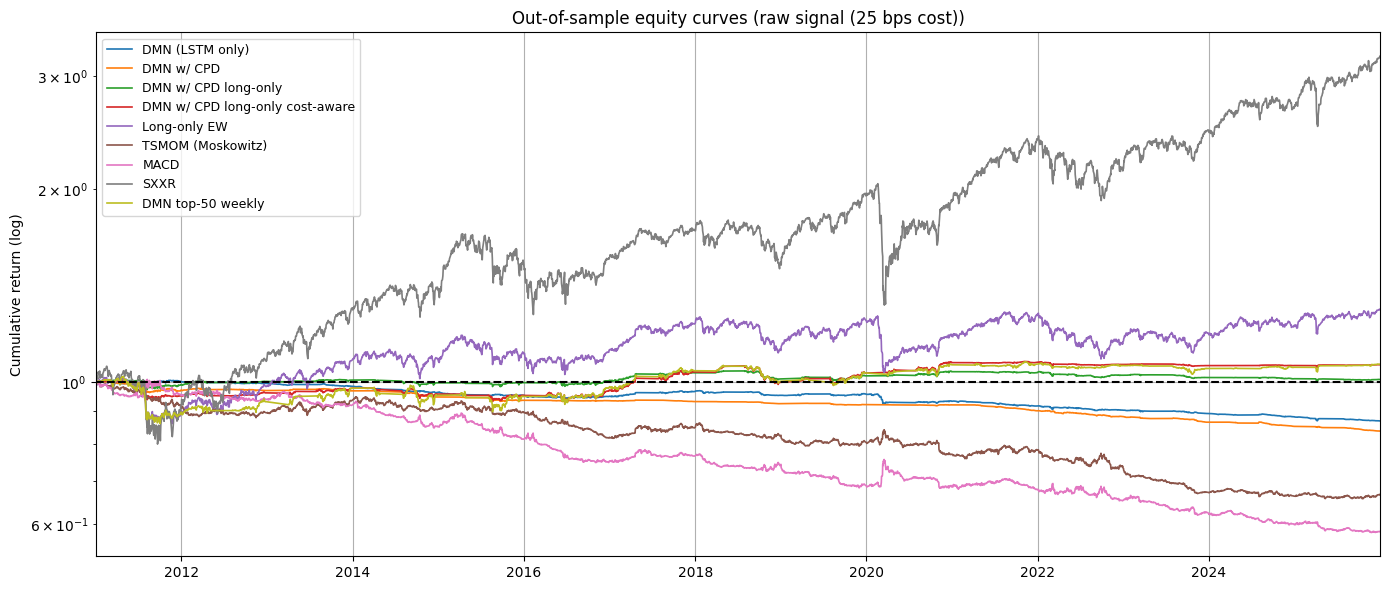

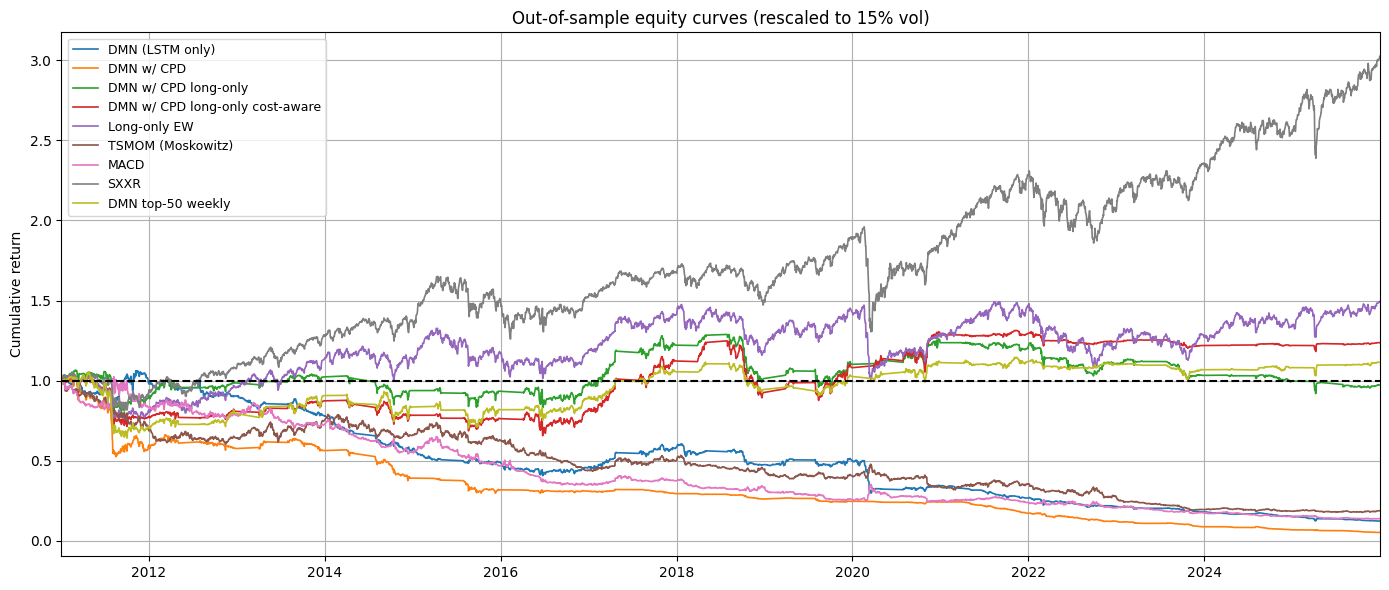

In [40]:
LABELS = {
    "dmn_baseline_net":           "DMN (LSTM only)",
    "dmn_cpd_net":                "DMN w/ CPD",
    "dmn_cpd_longonly_net":       "DMN w/ CPD long-only",
    "dmn_cpd_longonly_tc_net":    "DMN w/ CPD long-only cost-aware",
    "dmn_top50_weekly_net":       "DMN top-50 weekly",
    "long_only_net":              "Long-only EW",
    "moskowitz_net":              "TSMOM (Moskowitz)",
    "macd_net":                   "MACD",
    "sxxr":                       "SXXR",
}

def set_xlim_to_plotted_data(ax):
    lines = ax.get_lines()
    if not lines:
        return
    all_xdata = []
    for line in lines:
        all_xdata.extend(line.get_xdata())
    if all_xdata:
        valid_dates = [x for x in all_xdata if pd.notna(x)]
        if valid_dates:
            ax.set_xlim(min(valid_dates), max(valid_dates))

def plot_equity_curves(portfolios_dict, title_suffix, labels, log=False):
    fig, ax = plt.subplots(figsize=(14, 6))
    for label, ret in portfolios_dict.items():
        if label not in labels:
            continue
        cum = (1 + ret.dropna()).cumprod()
        ax.plot(cum.index, cum.values, lw=1.2, label=labels[label])
    
    set_xlim_to_plotted_data(ax)
    ax.axhline(1.0, color="black", lw=1.5, linestyle="--")
    
    if log:
        ax.set_yscale("log")
    ax.set_title(f"Out-of-sample equity curves ({title_suffix})")
    ax.set_ylabel("Cumulative return" + (" (log)" if log else ""))
    ax.legend(loc="upper left", fontsize=9)
    plt.tight_layout()
    plt.show()

plot_equity_curves(portfolios, f"raw signal ({TRANSACTION_COST*1e4:.0f} bps cost)", LABELS, log=True)
plot_equity_curves(rescaled, f"rescaled to {TARGET_VOL:.0%} vol", LABELS, log=False)

## Drawdown Analysis

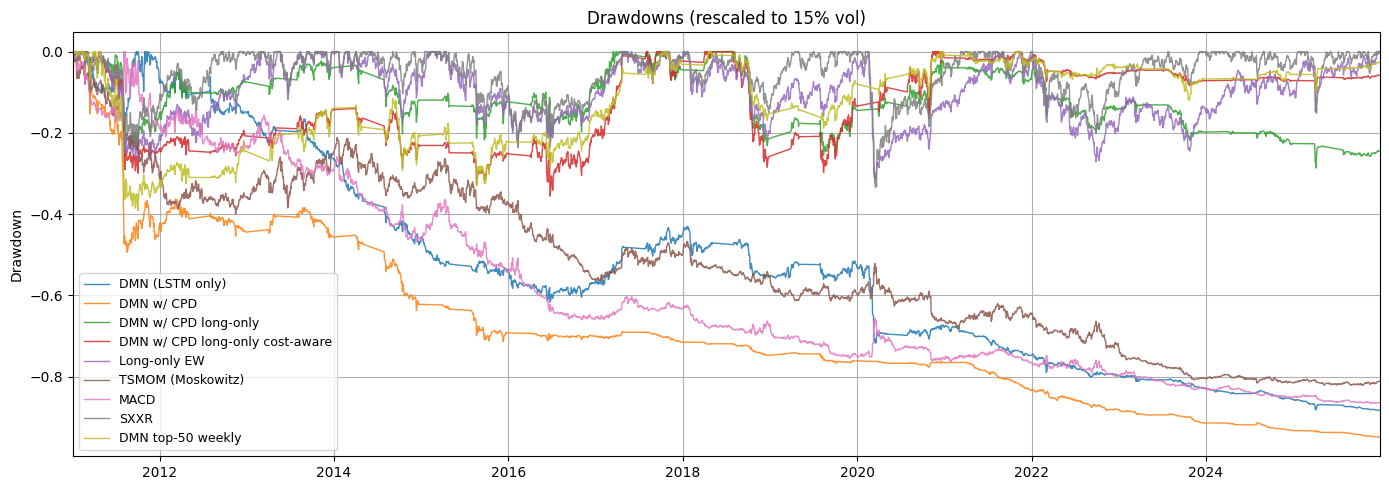

In [41]:
fig, ax = plt.subplots(figsize=(14, 5))
for label, ret in rescaled.items():
    if label not in LABELS:
        continue
    cum = (1 + ret.dropna()).cumprod()
    dd = (cum - cum.cummax()) / cum.cummax()
    ax.plot(dd.index, dd.values, lw=1.0, label=LABELS[label], alpha=0.85)

set_xlim_to_plotted_data(ax)
ax.set_title(f"Drawdowns (rescaled to {TARGET_VOL:.0%} vol)")
ax.set_ylabel("Drawdown")
ax.legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.show()

## Rolling Sharpe ratio
 
Trailing 252-day Sharpe assesses regime-dependence and the CPD module's value-add over time.


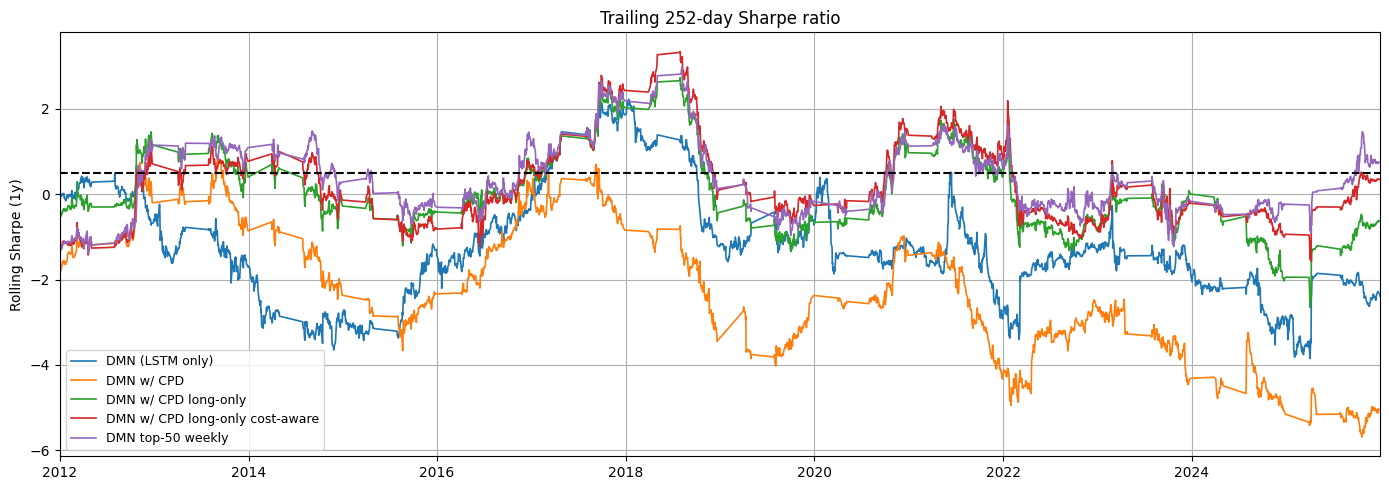

In [42]:
def rolling_sharpe(returns: pd.Series, window: int = 252) -> pd.Series:
    r = returns.dropna()
    return (r.rolling(window).mean() / r.rolling(window).std()) * np.sqrt(252)

fig, ax = plt.subplots(figsize=(14, 5))
for label in ["dmn_baseline_net", "dmn_cpd_net", "dmn_cpd_longonly_net", "dmn_cpd_longonly_tc_net", "dmn_top50_weekly_net"]:
    if label not in portfolios:
        continue
    rs = rolling_sharpe(portfolios[label])
    ax.plot(rs.index, rs.values, lw=1.2, label=LABELS[label])
ax.axhline(0.5, color="black", lw=1.5, linestyle="--")
ax.set_title("Trailing 252-day Sharpe ratio")
ax.set_ylabel("Rolling Sharpe (1y)")
ax.set_xlim(pd.to_datetime('2012-01-01'), pd.to_datetime('2025-12-31'))
ax.legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.show()

## Sharpe by year
 
Cross-year breakdown for regime-dependence analysis. The paper notes the CPD module is especially valuable in 2015-2020.

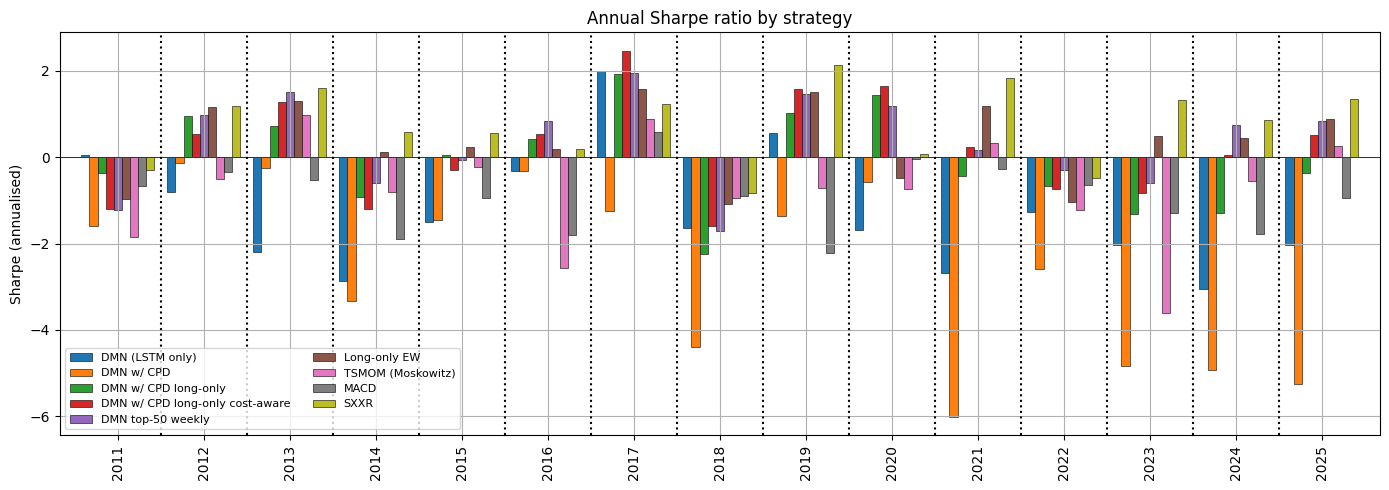


Sharpe by year:
      DMN (LSTM only)  DMN w/ CPD  DMN w/ CPD long-only  DMN w/ CPD long-only cost-aware  DMN top-50 weekly  Long-only EW  TSMOM (Moskowitz)  MACD  SXXR
date                                                                                                                                                    
2011             0.05       -1.59                 -0.37                            -1.19              -1.22         -0.98              -1.85 -0.66 -0.29
2012            -0.80       -0.13                  0.94                             0.54               0.98          1.15              -0.50 -0.34  1.18
2013            -2.21       -0.26                  0.72                             1.27               1.50          1.30               0.97 -0.52  1.60
2014            -2.87       -3.34                 -0.92                            -1.20              -0.59          0.12              -0.81 -1.90  0.58
2015            -1.51       -1.46                  0.06          

In [43]:
def yearly_sharpe(returns: pd.Series) -> pd.Series:
    r = returns.dropna()
    return r.groupby(r.index.year).apply(
        lambda y: (y.mean() / y.std()) * np.sqrt(252) if y.std() > 0 else 0.0
    )

# Build the yearly table for strategies we want to compare
yearly_table = pd.DataFrame({
    LABELS[label]: yearly_sharpe(portfolios[label])
    for label in LABELS if label in portfolios
})

fig, ax = plt.subplots(figsize=(14, 5))
yearly_table.plot(kind="bar", ax=ax,width=0.85, edgecolor="black", linewidth=0.4,)
for x in range(len(yearly_table) - 1):
    # Placing the line exactly halfway between the bars of adjacent years
    ax.axvline(x=x + 0.5, color="black", linestyle=":", alpha=1)
ax.set_title("Annual Sharpe ratio by strategy")
ax.set_ylabel("Sharpe (annualised)"); ax.set_xlabel("")
ax.axhline(0, color="black", lw=0.5)
ax.legend(fontsize=8, ncol=2, loc="lower left")
plt.tight_layout()
plt.show()

print(f"\nSharpe by year:")
print(yearly_table.round(2).to_string())

## Transaction cost sensitivity (paper Exhibit 8)
 
How does Sharpe degrade as we increase per-transaction cost from 0 bps to 50 bps? The paper notes DMNs deteriorate quickly above ~2 bps without a cost-aware loss; with a cost-aware model (`dmn_cpd_longonly_tc` variant), we have a slower degradation.

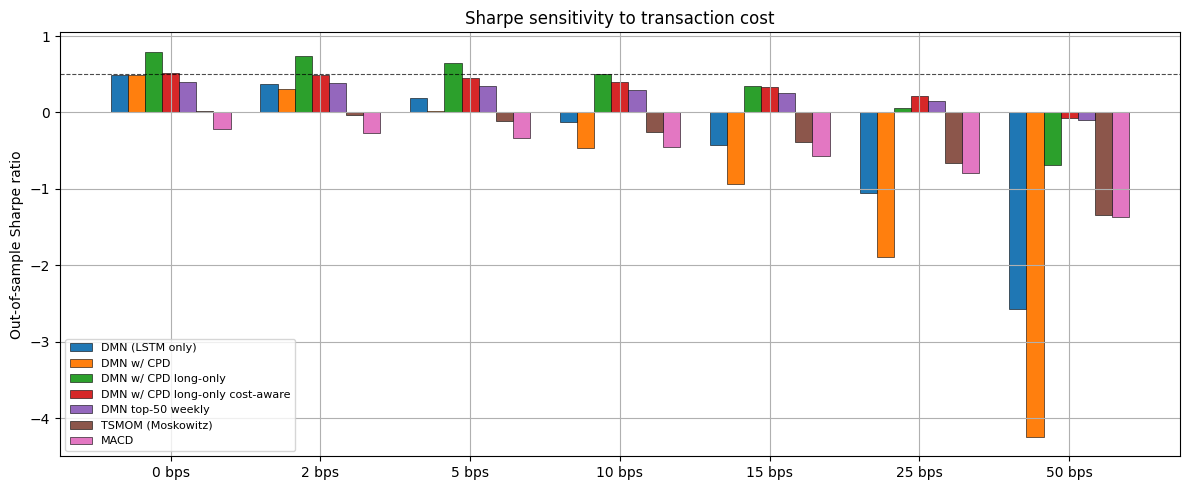

In [44]:
COST_GRID_BPS = [0, 2, 5, 10, 15, 25, 50]
COST_GRID = [c * 1e-4 for c in COST_GRID_BPS]

def sharpe_at_cost(df: pd.DataFrame, cost: float, position_col="position",
                    vol_col="ex_ante_vol", gross_col="strat_ret_gross") -> float:
    """Re-derive Sharpe after subtracting per-ticker turnover cost."""
    adj = add_transaction_costs(
        df, position_col=position_col, vol_col=vol_col,
        gross_col=gross_col, net_col="_tmp_net", cost=cost
    )
    port = to_portfolio_series(adj, "_tmp_net")
    return compute_metrics(port).get("Sharpe", np.nan)

COST_SENS_VARIANTS = ["dmn_baseline","dmn_cpd","dmn_cpd_longonly","dmn_cpd_longonly_tc","dmn_top50_weekly"]

cost_sens = {}
for label in COST_SENS_VARIANTS:
    if label in dmn_predictions:
        cost_sens[label] = [sharpe_at_cost(dmn_predictions[label], c) for c in COST_GRID]

for name in ["moskowitz", "macd"]:
    sharpes = []
    for c in COST_GRID:
        sharpes.append(sharpe_at_cost(
            classical, c,
            position_col=f"pos_{name}", vol_col="60d_ewm_vol",
            gross_col=f"strat_{name}_gross"
        ))
    cost_sens[name] = sharpes

cost_table = pd.DataFrame(cost_sens, index=COST_GRID_BPS)
cost_table.index.name = "Cost (bps)"
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(COST_GRID_BPS))
n_series = len(cost_table.columns)
width = 0.8 / n_series

for i, label in enumerate(cost_table.columns):
    display_label = LABELS.get(label + "_net", LABELS.get(label, label))
    offset = (i - n_series / 2 + 0.5) * width
    ax.bar(x + offset, cost_table[label].values, width,
           label=display_label, edgecolor="black", linewidth=0.4)

ax.axhline(0.5, color="black", lw=0.8, linestyle="--", alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels([f"{c} bps" for c in COST_GRID_BPS])
ax.set_ylabel("Out-of-sample Sharpe ratio")
ax.set_title("Sharpe sensitivity to transaction cost")
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout(); plt.show()

In [45]:
#print("Unique tickers per year in OOS panel:")
#print(stocks_oos.groupby(stocks_oos["date"].dt.year)["ticker"].nunique())
# They should be exactly 600 

## CPD lookback window sensitivity 

Compares the long-only cost-aware DMN trained with CPD computed with different lookback windows, i.e. `lbw`$\in \{10,21,63,126,252\}$. All of them use the same stride and fold type. The default choice appears to be `lbw`=21 (monthly regime detection).

10d LBW: 396,402 rows, 2011-01-03 2025-12-30
21d LBW: 396,402 rows, 2011-01-03 2025-12-30
63d LBW: 393,308 rows, 2011-01-03 2025-12-30
126d LBW: 297,826 rows, 2011-01-03 2025-12-30
  252d LBW: no files matching predictions_fold*_expanding_cpd252_s1_longonly_tc25bps.csv — skipping


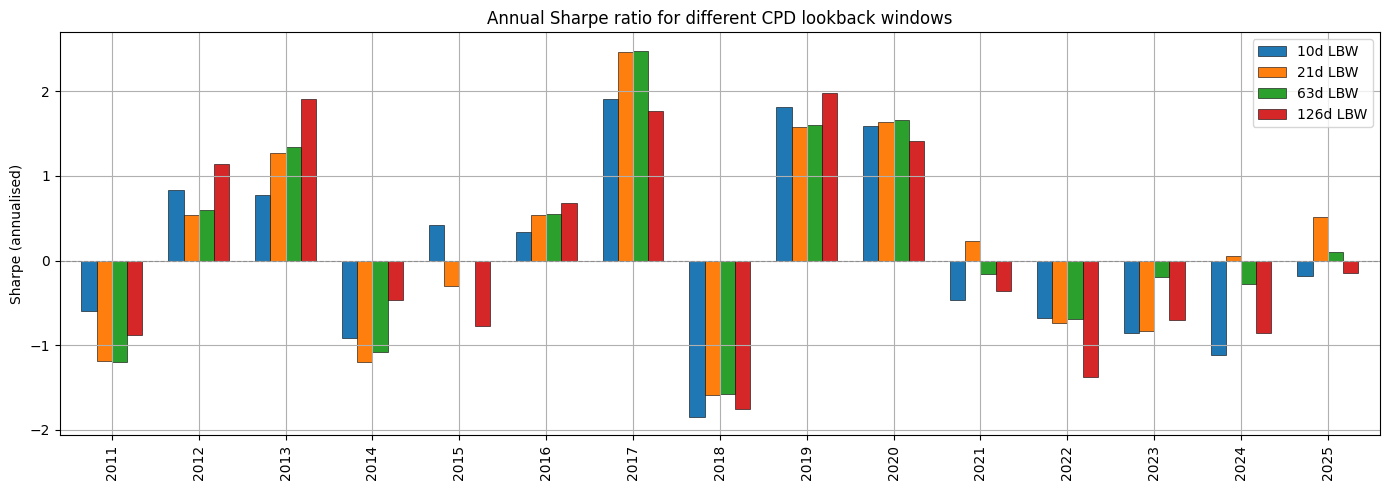

      10d LBW  21d LBW  63d LBW  126d LBW
date                                     
2011    -0.60    -1.19    -1.20     -0.88
2012     0.83     0.54     0.60      1.14
2013     0.78     1.27     1.34      1.91
2014    -0.92    -1.20    -1.09     -0.47
2015     0.41    -0.30    -0.01     -0.78
2016     0.33     0.54     0.54      0.68
2017     1.91     2.47     2.48      1.77
2018    -1.85    -1.59    -1.58     -1.76
2019     1.81     1.58     1.61      1.98
2020     1.60     1.64     1.66      1.41
2021    -0.47     0.23    -0.16     -0.36
2022    -0.68    -0.74    -0.69     -1.38
2023    -0.86    -0.84    -0.19     -0.70
2024    -1.11     0.06    -0.28     -0.86
2025    -0.18     0.52     0.11     -0.15


In [46]:
lbw_variants = {
    "10d LBW": f"{FOLD_TYPE}_cpd10_s{CPD_STRIDE}_longonly_tc25bps",
    "21d LBW": f"{FOLD_TYPE}_cpd21_s{CPD_STRIDE}_longonly_tc25bps",
    "63d LBW": f"{FOLD_TYPE}_cpd63_s{CPD_STRIDE}_longonly_tc25bps",
    "126d LBW": f"{FOLD_TYPE}_cpd126_s{CPD_STRIDE}_longonly_tc25bps",
    "252d LBW": f"{FOLD_TYPE}_cpd252_s{CPD_STRIDE}_longonly_tc25bps",
}

lbw_predictions = {}
for label, suffix in lbw_variants.items():
    df = load_variant(suffix)
    if df.empty:
        print(f"  {label}: no files matching predictions_fold*_{suffix}.csv — skipping")
        continue
    if "strat_ret_gross" not in df.columns:
        df["strat_ret_gross"] = df["strat_ret"].copy()
    lbw_predictions[label] = add_transaction_costs(
        df, position_col="position", vol_col="ex_ante_vol",
        gross_col="strat_ret_gross", net_col="strat_ret"
    )
    print(f"{label}: {len(df):,} rows, {df['date'].min().date()} {df['date'].max().date()}")

if not lbw_predictions:
    raise FileNotFoundError("No LBW comparison predictions found.")

# Build portfolio series (net of costs) for each LBW
lbw_portfolios = {
    label: to_portfolio_series(df, "strat_ret")
    for label, df in lbw_predictions.items()
}

# Compute yearly Sharpe for each
lbw_yearly_table = pd.DataFrame({
    label: yearly_sharpe(port)
    for label, port in lbw_portfolios.items()
})

fig, ax = plt.subplots(figsize=(14, 5))
lbw_yearly_table.plot(kind="bar", ax=ax,width=0.7, edgecolor="black", linewidth=0.4,)
ax.axhline(0, color="gray", lw=0.8, linestyle="--", alpha=0.7)
ax.set_title("Annual Sharpe ratio for different CPD lookback windows")
ax.set_ylabel("Sharpe (annualised)"); ax.set_xlabel("")
ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

print(lbw_yearly_table.round(2).to_string())

`lbw`=252 could not be evaluated under the expanding fold structure: fold 0's 5-year training window (2006–2010) is shorter than the combined CPD warm-up period (252 days) and LSTM sequence length (63 days), leaving no valid training sequences. Results for `lbw`=252 are therefore reported under the rolling-window structure only, where the minimum training window (10 years) comfortably accommodates this requirement.

The four variants move in near-lockstep across all 15 out-of-sample years, with agreement in sign (almost) every year and similar magnitude. This indicates that performance is driven primarily by the underlying momentum signal and prevailing market regime rather than by the specific CPD timescale, and is consistent with our earlier finding that the CPD module contributes limited incremental information on single-stock equities relative to the existing vol-normalised return and MACD features.

## Robustness: GARCH(1,1) volatility scaling

The main results use 60-day EWMA volatility for the position-scaling  (paper Eq. 11). As a robustness check, we recompute strategy returns using GARCH(1,1) conditional volatility instead, keeping the same learned positions from the DMN. This isolates the effect of the volatility estimator on performance.

In [47]:
garch_panel = pd.read_csv(
    PROCESSED_DIR / "stoxx600_processed.csv",
    parse_dates=["date"],
    usecols=["date", "ticker", "garch_vol_daily"],
)
# Annualise (stored as daily in the CSV)
garch_panel["garch_vol"] = garch_panel["garch_vol_daily"] * np.sqrt(252)
garch_panel = garch_panel.drop(columns=["garch_vol_daily"])

print(f"GARCH vol loaded: {len(garch_panel):,} rows, "
      f"{garch_panel['garch_vol'].notna().mean():.1%} coverage")

# Recompute strategy returns for each DMN variant using GARCH vol
robustness_rows = []

for label, df_pred in dmn_predictions.items():
    # Merge GARCH vol onto predictions
    merged = df_pred.merge(garch_panel, on=["date", "ticker"], how="left")
    
    # Recompute strategy return with GARCH vol instead of EWMA
    merged["strat_ret_garch"] = (
        merged["position"]
        * (TARGET_VOL / np.maximum(merged["garch_vol"], 1e-6))
        * merged["ret"]
    )
    
    # Apply transaction costs (same 25 bps, but turnover now uses GARCH vol)
    merged = merged.sort_values(["ticker", "date"])
    scaled_pos_garch = merged["position"] / np.maximum(merged["garch_vol"], 1e-6)
    turnover = scaled_pos_garch.groupby(merged["ticker"]).diff().abs().fillna(0.0)
    merged["strat_ret_garch_net"] = (
        merged["strat_ret_garch"] - TRANSACTION_COST * TARGET_VOL * turnover
    )
    
    # Portfolio-level (EW across stocks per day)
    port_ewma_net  = to_portfolio_series(df_pred, "strat_ret")
    port_garch_net = merged.groupby("date")["strat_ret_garch_net"].mean().sort_index()
    
    m_ewma  = compute_metrics(port_ewma_net)
    m_garch = compute_metrics(port_garch_net)
    
    robustness_rows.append({
        "Strategy": label,
        "Vol Model": "EWMA (60d)",
        **m_ewma,
    })
    robustness_rows.append({
        "Strategy": label,
        "Vol Model": "GARCH(1,1)",
        **m_garch,
    })

robustness_df = (pd.DataFrame(robustness_rows)
                  .set_index(["Strategy", "Vol Model"]))

robustness_df_formatted = format_metrics(robustness_df)
robustness_display = robustness_df_formatted[["Returns", "Vol", "Sharpe", "MDD", "Calmar"]]

print("\nRobustness check: EWMA vs GARCH(1,1) volatility scaling")
print(f"({TRANSACTION_COST*1e4:.0f} bps backtest costs applied to both)\n")
print(robustness_display.to_string())

GARCH vol loaded: 3,149,892 rows, 99.0% coverage

Robustness check: EWMA vs GARCH(1,1) volatility scaling
(25 bps backtest costs applied to both)

                               Returns     Vol  Sharpe      MDD  Calmar
Strategy            Vol Model                                          
dmn_baseline        EWMA (60d)  -1.13%  +1.08%  -1.048  -13.57%  -0.083
                    GARCH(1,1)  -1.08%  +0.98%  -1.103  -13.17%  -0.082
dmn_cpd             EWMA (60d)  -1.78%  +0.94%  -1.896  -16.41%  -0.108
                    GARCH(1,1)  -1.60%  +0.88%  -1.809  -14.92%  -0.107
dmn_cpd_longonly    EWMA (60d)  +0.10%  +1.84%  +0.056   -3.71%  +0.028
                    GARCH(1,1)  +0.14%  +1.71%  +0.080   -3.39%  +0.041
dmn_cpd_longonly_tc EWMA (60d)  +0.67%  +3.06%  +0.218   -7.83%  +0.085
                    GARCH(1,1)  +0.54%  +2.86%  +0.188   -7.37%  +0.073
dmn_top50_daily     EWMA (60d)  +0.53%  +5.34%  +0.098  -16.03%  +0.033
                    GARCH(1,1)  +0.38%  +4.96%  +0.076  -14.7